In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from umap import UMAP

In [20]:
data = pd.read_csv("../data/city_lifestyle_dataset.csv")

X = data.select_dtypes(include=["float64", "int64"])

In [21]:
data

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5
...,...,...,...,...,...,...,...,...,...,...
295,Old Harbor,Oceania,1004,4620,100.0,1500,40,64.2,8.5,50.2
296,Ridgehaven,Oceania,1652,4500,100.0,1650,44,49.3,8.5,37.4
297,North Field,Oceania,836,3910,98.7,1340,40,55.7,8.5,38.6
298,Bridgeford,Oceania,758,3490,91.2,1390,36,54.1,8.5,44.6


In [22]:
X = data.drop(columns=["country", "city_name"])

In [23]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   population_density      300 non-null    int64  
 1   avg_income              300 non-null    int64  
 2   internet_penetration    300 non-null    float64
 3   avg_rent                300 non-null    int64  
 4   air_quality_index       300 non-null    int64  
 5   public_transport_score  300 non-null    float64
 6   happiness_score         300 non-null    float64
 7   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 18.9 KB


In [24]:
data["country"].unique()

array(['Europe', 'Asia', 'North America', 'South America', 'Africa',
       'Oceania'], dtype=object)

### Visualisation de la projection UMAP

Chaque point représente une ville, colorée selon son pays d'appartenance. On peut observer si les villes d'un même pays ont tendance à se regrouper dans l'espace projeté, ce qui indiquerait que les variables du dataset (mode de vie, coût, etc.) varient significativement d'un pays à l'autre.

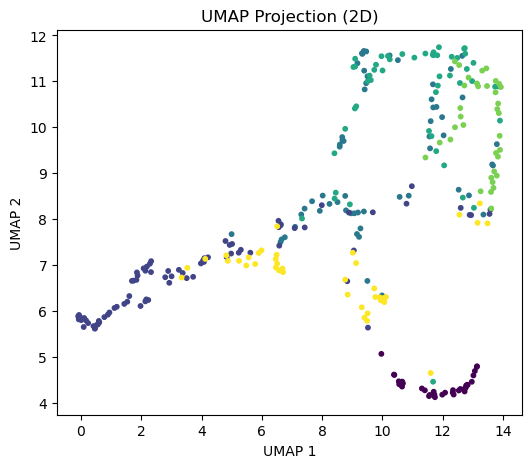

In [25]:
plt.figure(figsize=(6, 5))
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=data["country"].astype("category").cat.codes,
    s=10
)
plt.title("UMAP Projection (2D)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [26]:
umap_df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
umap_df.to_csv("../outputs/umap_emb_2d.csv", index=False)